In [1]:
# ── CELDA 1: Importaciones ────────────────────────────────────
import sys
import os

# Agrega la raíz del proyecto al path para importar scripts/
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 🔗 Motor de base de datos (IMPORTANTE)
from scripts.database import engine

# 🎨 Estilo visual
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print("✅ Librerías importadas correctamente")
print(f"   pandas      {pd.__version__}")
print(f"   numpy       {np.__version__}")
print(f"   seaborn     {sns.__version__}")
print(f"   statsmodels {sm.__version__}")

✅ Librerías importadas correctamente
   pandas      2.2.2
   numpy       1.26.4
   seaborn     0.13.2
   statsmodels 0.14.6


In [2]:
# ── CELDA 2: Carga de datos desde PostgreSQL ─────────────────
QUERY = """
SELECT
    id,
    nombre,
    inteligencia,
    fuerza,
    velocidad,
    durabilidad,
    poder,
    combate,
    nombre_completo,
    editor,
    alineacion,
    genero,
    raza,
    altura,
    peso,
    fecha_extraccion,
    promedio_poder,
    ranking
FROM superheroes
ORDER BY ranking, id
"""

df = pd.read_sql(QUERY, engine)

print(f"✅ Datos cargados exitosamente desde PostgreSQL")
print(f"   Filas    : {df.shape[0]:,}")
print(f"   Columnas : {df.shape[1]}")
print(f"\n📋 Primeras filas:")
df.head()

✅ Datos cargados exitosamente desde PostgreSQL
   Filas    : 731
   Columnas : 18

📋 Primeras filas:


,id,nombre,inteligencia,fuerza,velocidad,durabilidad,poder,combate,nombre_completo,editor,alineacion,genero,raza,altura,peso,fecha_extraccion,promedio_poder,ranking
0,426,Man of Miracles,100,100,100,100,100,100,Desconocido,Image Comics,Desconocido,Desconocido,God / Eternal,"-, 0 cm","- lb, 0 kg",2026-04-15 20:11:17,100.00,1.0
1,503,One-Above-All,100,100,100,100,100,100,Desconocido,Marvel Comics,neutral,Desconocido,Cosmic Entity,"-, 0 cm","- lb, 0 kg",2026-04-15 20:11:17,100.00,1.0
2,278,General Zod,94,100,96,100,100,95,Dru-Zod,DC Comics,bad,Male,Kryptonian,"-, 0 cm","- lb, 0 kg",2026-04-15 20:11:17,97.50,3.0
3,80,Beyonder,100,100,100,100,100,84,Desconocido,Marvel Comics,good,Male,God / Eternal,"-, 0 cm","- lb, 0 kg",2026-04-15 20:11:17,97.33,4.0
4,642,Superboy-Prime,94,100,100,100,100,85,Kal-El,DC Comics,bad,Male,Kryptonian,"5'11, 180 cm","170 lb, 77 kg",2026-04-15 20:11:17,96.50,5.0


In [3]:
# ── CELDA 3: Inspección del DataFrame ────────────────────────

print("=" * 50)
print("  INFORMACIÓN GENERAL DEL DATASET")
print("=" * 50)

df.info()

print("\n📊 Valores nulos por columna:")
print(df.isnull().sum())

print("\n🦸‍♂️ Frecuencia de todos los superhéroes:")
print(df['nombre'].value_counts())

print("\n🏆 Ranking completo (ordenado):")
print(df[['nombre', 'ranking']].sort_values(by='ranking'))

  INFORMACIÓN GENERAL DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id                731 non-null    int64         
 1   nombre            731 non-null    object        
 2   inteligencia      731 non-null    int64         
 3   fuerza            731 non-null    int64         
 4   velocidad         731 non-null    int64         
 5   durabilidad       731 non-null    int64         
 6   poder             731 non-null    int64         
 7   combate           731 non-null    int64         
 8   nombre_completo   731 non-null    object        
 9   editor            731 non-null    object        
 10  alineacion        731 non-null    object        
 11  genero            731 non-null    object        
 12  raza              731 non-null    object        
 13  altura            731 non-null    object      

In [4]:
# ── CELDA 4: Estadísticas descriptivas ───────────────────────
vars_num = [
    'inteligencia',
    'fuerza',
    'velocidad',
    'durabilidad',
    'poder',
    'combate',
    'promedio_poder',
    'ranking'
]

desc = df[vars_num].describe().round(2)

print("📊 ESTADÍSTICAS DESCRIPTIVAS")
print(desc)

📊 ESTADÍSTICAS DESCRIPTIVAS
       inteligencia  fuerza  velocidad  durabilidad   poder  combate  \
count        731.00  731.00     731.00       731.00  731.00   731.00   
mean          49.90   37.86      31.16        45.66   49.74    47.69   
std           32.19   34.11      27.29        36.17   37.54    32.95   
min            0.00    0.00       0.00         0.00    0.00     0.00   
25%           25.00   10.00       8.00        10.00   12.50    14.00   
50%           56.00   28.00      27.00        42.00   50.00    56.00   
75%           75.00   67.00      46.50        80.00   88.50    75.00   
max          100.00  100.00     100.00       110.00  100.00   101.00   

       promedio_poder  ranking  
count          731.00   731.00  
mean            43.67   358.36  
std             26.98   200.98  
min              0.00     1.00  
25%             24.84   183.00  
50%             46.67   366.00  
75%             63.33   548.50  
max            100.00   630.00  


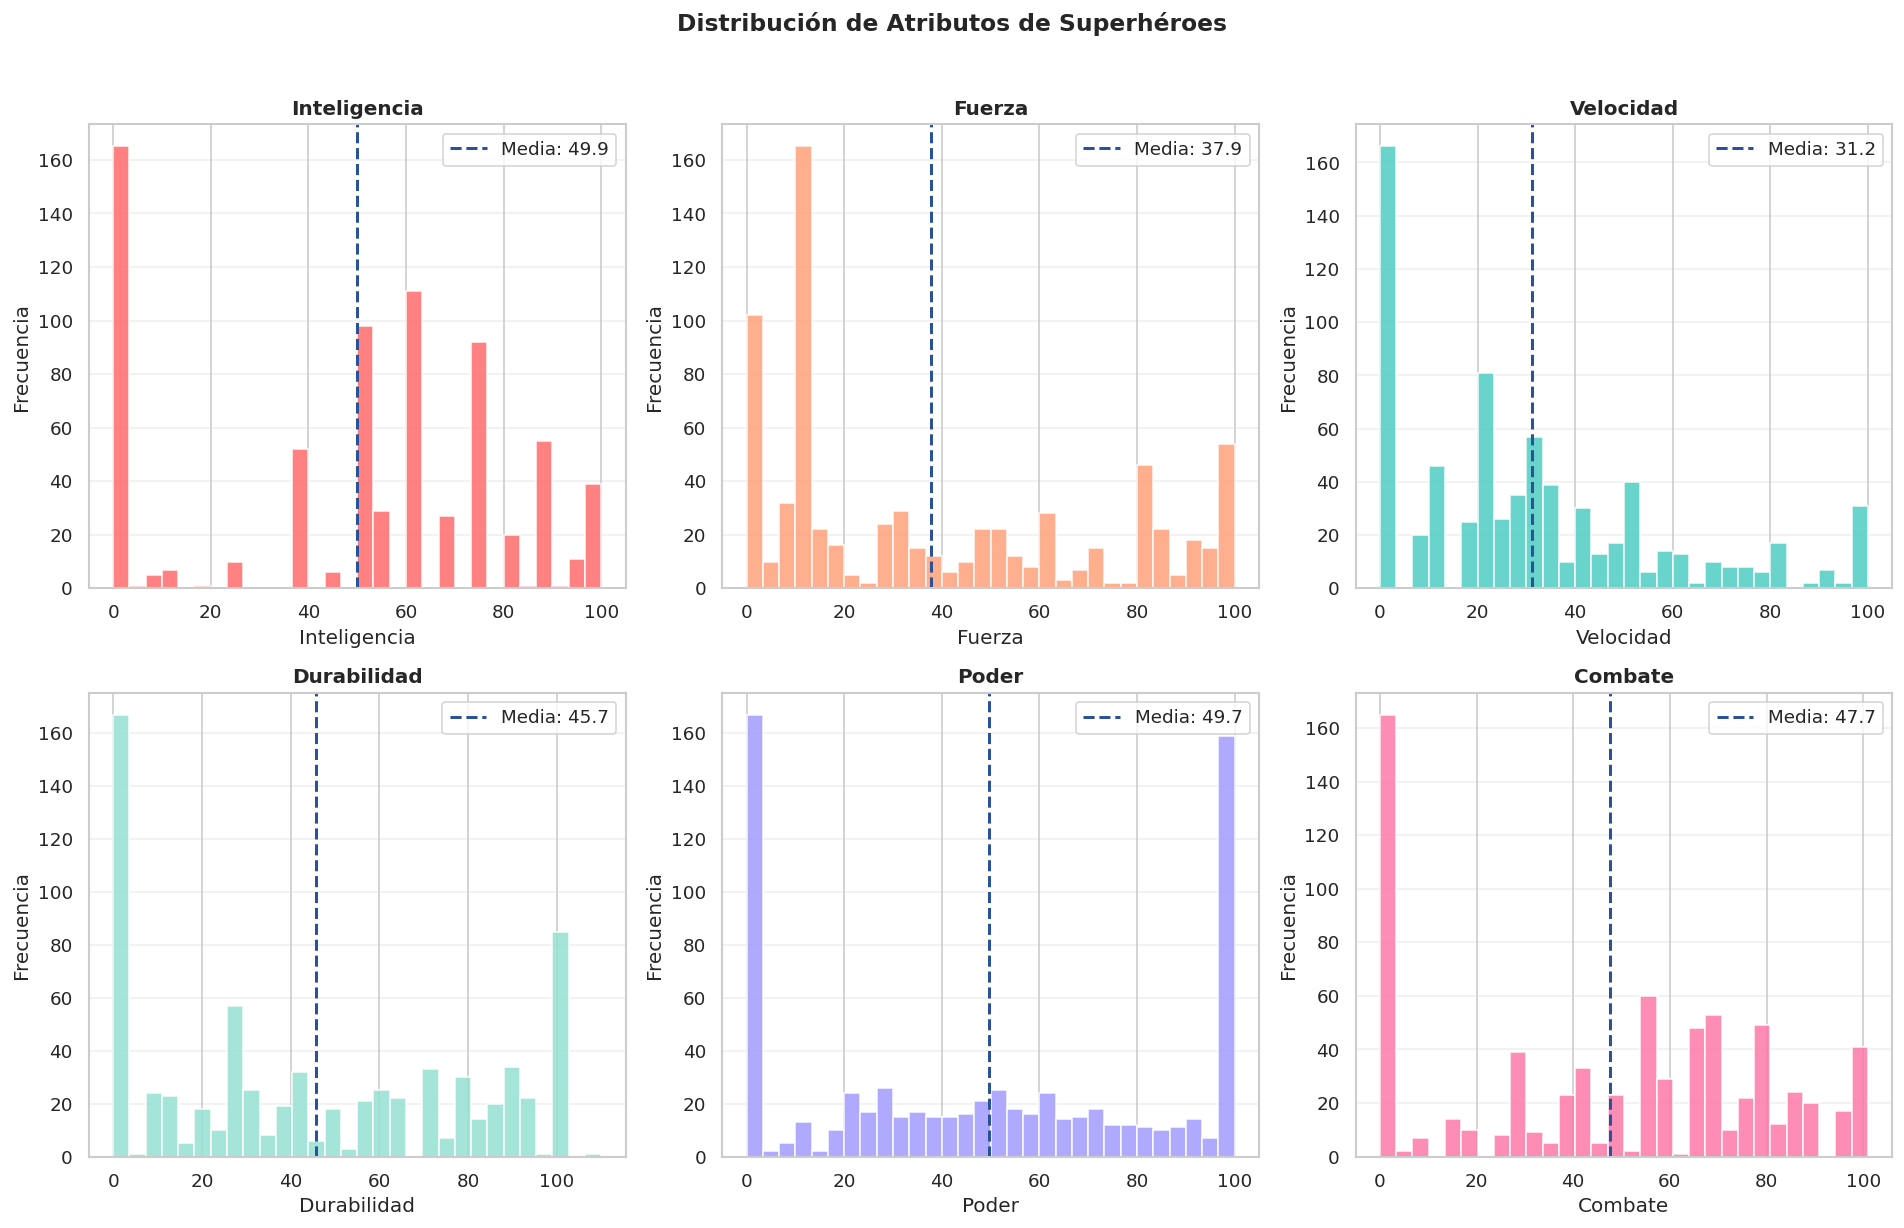

In [5]:
# ── CELDA 5: Histogramas de distribución ─────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distribución de Atributos de Superhéroes',
             fontsize=14, fontweight='bold', y=1.02)

datos = {
    'inteligencia': ('Inteligencia', '#ff6b6b'),
    'fuerza':       ('Fuerza', '#ffa07a'),
    'velocidad':    ('Velocidad', '#4ecdc4'),
    'durabilidad':  ('Durabilidad', '#95e1d3'),
    'poder':        ('Poder', '#a29bfe'),
    'combate':      ('Combate', '#fd79a8'),
}

for ax, (col, (label, color)) in zip(axes.flat, datos.items()):
    ax.hist(df[col], bins=30, color=color, edgecolor='white', alpha=0.85)
    
    media = df[col].mean()
    ax.axvline(media, color='#2a5298', linestyle='--', linewidth=1.8,
               label=f'Media: {media:.1f}')
    
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Frecuencia')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/eda_distribuciones_superheroes.png',
            dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_6929/372628033.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top10, x='editor', y='poder',
/tmp/ipykernel_6929/372628033.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top10, x='editor', y='combate',


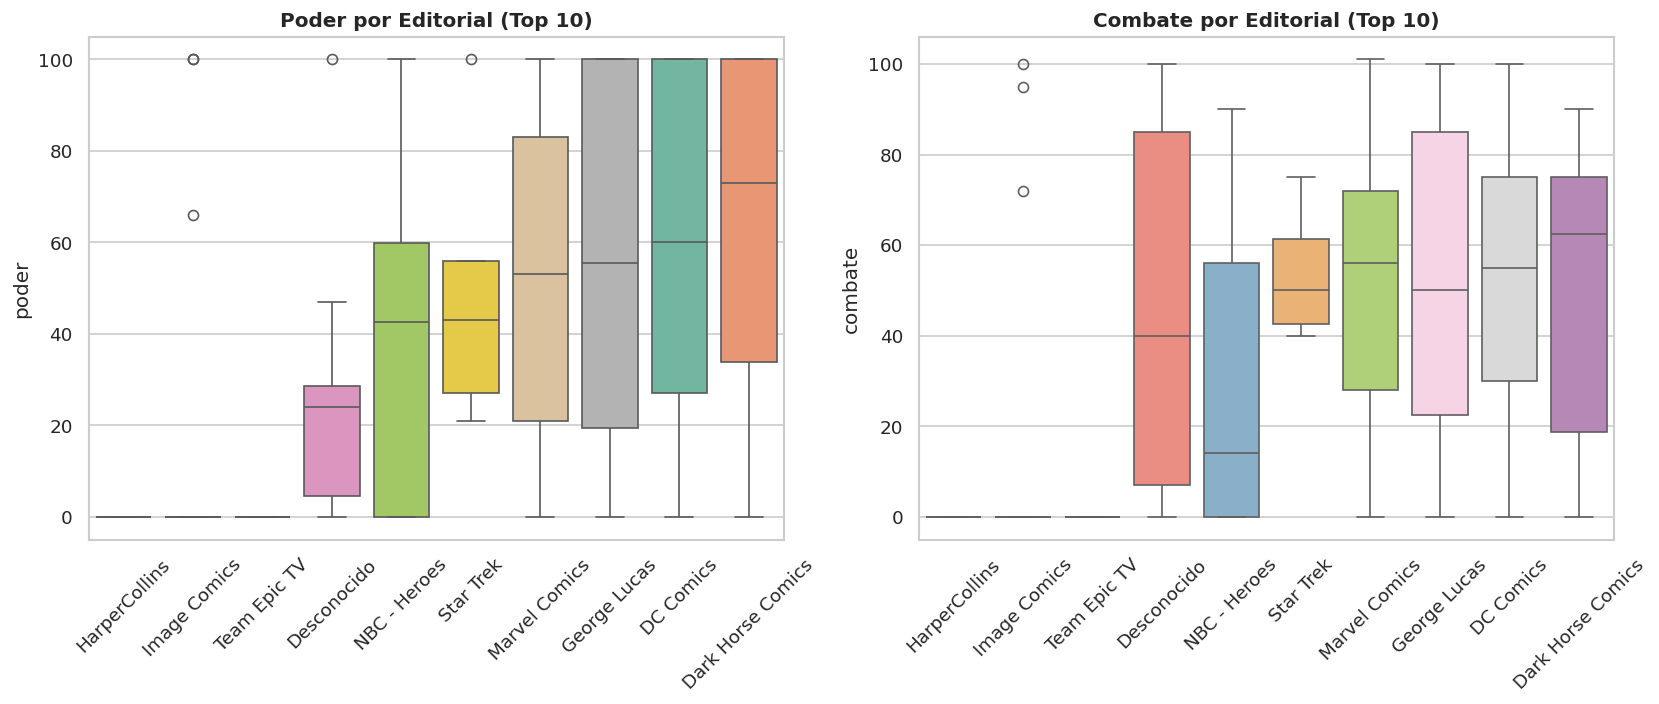

In [6]:
# ── CELDA 6: Boxplots por editorial (Grafica de Cajas) (Top 10) ─────────────────

top10_editoriales = df["editor"].value_counts().head(10).index
df_top10 = df[df["editor"].isin(top10_editoriales)].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

orden = df_top10.groupby('editor')['poder'].median().sort_values().index

sns.boxplot(data=df_top10, x='editor', y='poder',
            order=orden, palette='Set2', ax=axes[0])
axes[0].set_title('Poder por Editorial (Top 10)', fontweight='bold')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(data=df_top10, x='editor', y='combate',
            order=orden, palette='Set3', ax=axes[1])
axes[1].set_title('Combate por Editorial (Top 10)', fontweight='bold')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../data/graficas/eda_boxplots_editorial_top10.png',
            dpi=150, bbox_inches='tight')
plt.show()

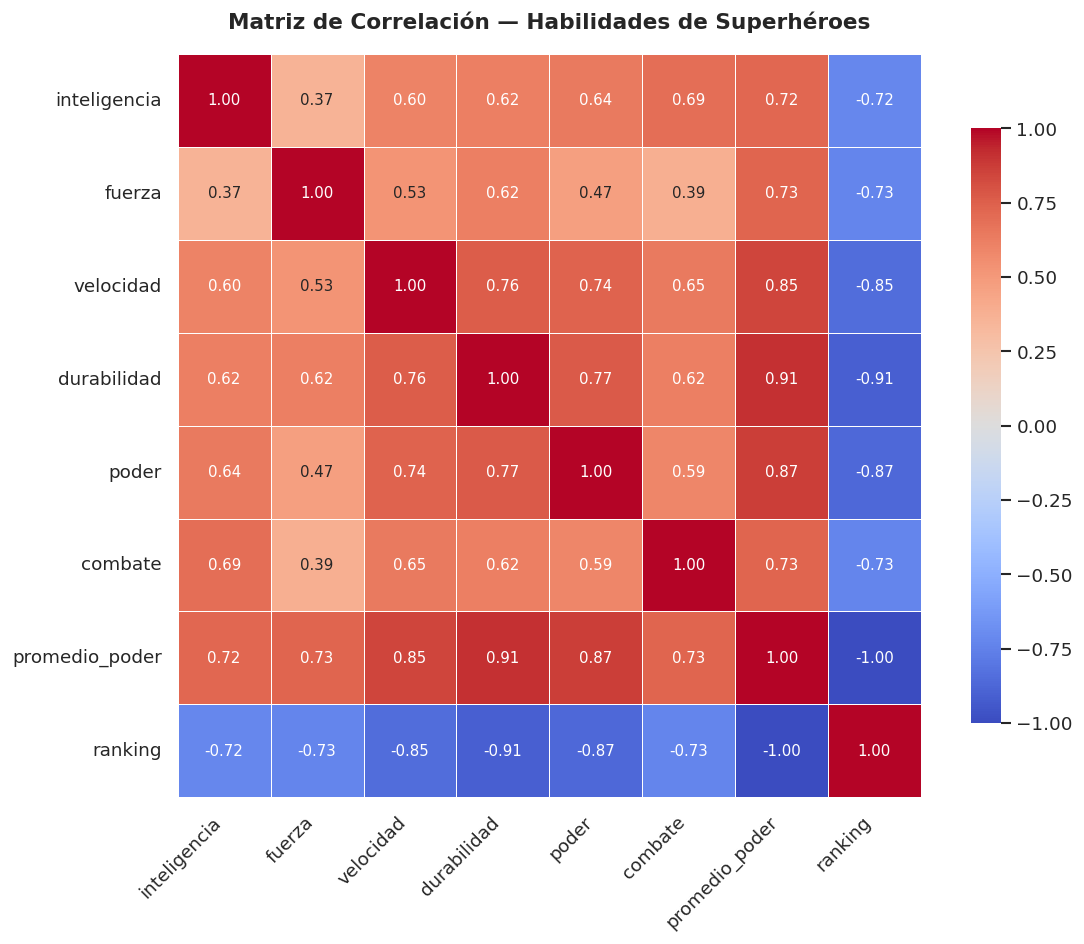


📊 Correlación con durabilidad (ordenada):
promedio_poder    0.9066
poder             0.7712
velocidad         0.7619
fuerza            0.6206
combate           0.6196
inteligencia      0.6181
ranking          -0.9066
Name: durabilidad, dtype: float64


In [7]:
# ── CELDA 7: Matriz de correlación ───────────────────────────

corr = df[vars_num].corr(method='spearman')

plt.figure(figsize=(10, 8))  # más espacio

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',  # menos decimales
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={'shrink': 0.8},
    annot_kws={'size': 9}  # números más pequeños
)

# Mejorar etiquetas
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.title(
    'Matriz de Correlación — Habilidades de Superhéroes',
    fontsize=13,
    fontweight='bold',
    pad=15
)

plt.tight_layout()

plt.savefig(
    '../data/graficas/eda_correlacion_superheroes.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("\n📊 Correlación con durabilidad (ordenada):")
print(
    corr['durabilidad']
    .drop('durabilidad')
    .sort_values(ascending=False)
    .round(4)
)

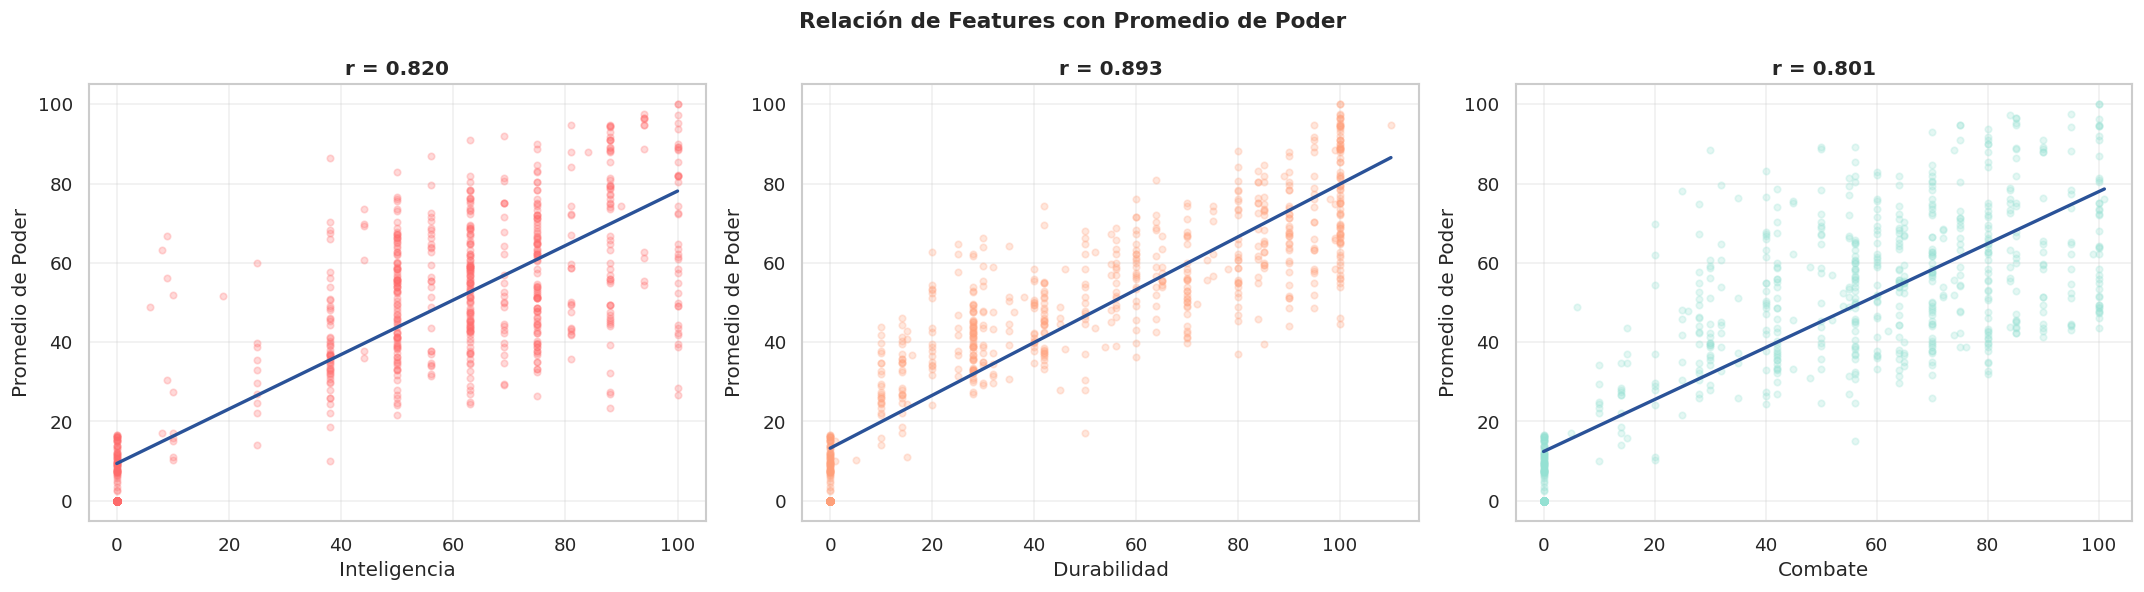

In [8]:
# ── CELDA 8: Scatter plots inteligencia/durabilidad/combate vs promedio_poder ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Relación de Features con Promedio de Poder',
             fontsize=13, fontweight='bold')

pares = [
    ('inteligencia', 'Inteligencia', '#ff6b6b'),
    ('durabilidad',  'Durabilidad',  '#ffa07a'),
    ('combate',      'Combate',      '#95e1d3'),
]

for ax, (feature, xlabel, color) in zip(axes, pares):
    ax.scatter(df[feature], df['promedio_poder'],
               alpha=0.25, s=15, color=color)

    z = np.polyfit(df[feature], df['promedio_poder'], 1)
    p = np.poly1d(z)
    xp = np.linspace(df[feature].min(), df[feature].max(), 200)
    ax.plot(xp, p(xp), color='#2a5298', linewidth=2)

    r = df[[feature, 'promedio_poder']].corr().iloc[0, 1]

    ax.set_title(f'r = {r:.3f}', fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Promedio de Poder')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/eda_scatter_superheroes.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# ── CELDA 9: Split Train / Test ───────────────────────────────
from sklearn.model_selection import train_test_split

# Modelo simple: durabilidad → promedio_poder
X_simple = df[["durabilidad"]].values
y = df["promedio_poder"].values

mask = ~pd.isnull(X_simple.flatten()) & ~pd.isnull(y)
X_simple = X_simple[mask]
y = y[mask]

X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.20, random_state=42
)

print(f"Train: {X_train.shape[0]:,} muestras")
print(f"Test : {X_test.shape[0]:,} muestras")

Train: 584 muestras
Test : 147 muestras


In [10]:
# ── CELDA 10: Entrenamiento con scikit-learn ──────────────────

modelo_simple = LinearRegression()
modelo_simple.fit(X_train, y_train)

y_pred_simple = modelo_simple.predict(X_test)

print(f"Intercepto  β₀ : {modelo_simple.intercept_:.4f}")
print(f"Coeficiente β₁ : {modelo_simple.coef_[0]:.4f}")

print(f"\nEcuación : promedio_poder = {modelo_simple.intercept_:.3f}"
      f" + {modelo_simple.coef_[0]:.3f} × durabilidad")

Intercepto  β₀ : 13.1845
Coeficiente β₁ : 0.6643

Ecuación : promedio_poder = 13.184 + 0.664 × durabilidad


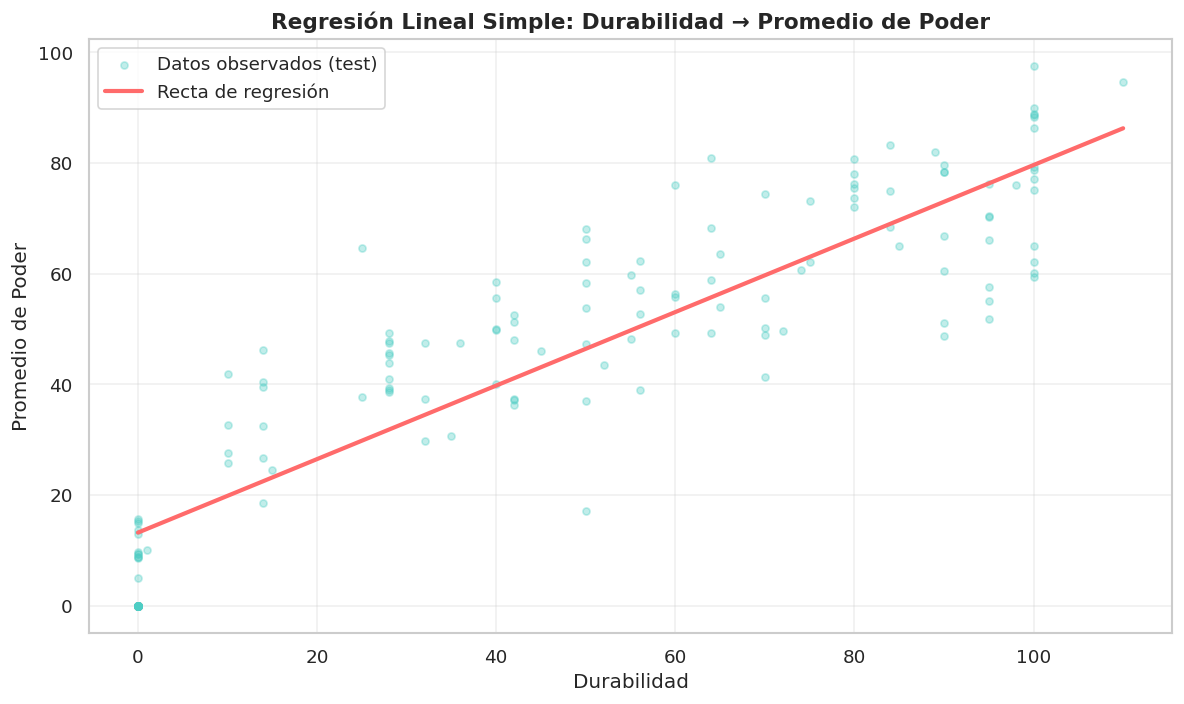

In [11]:
# ── CELDA 11: Recta de regresión ─────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(X_test, y_test, alpha=0.35, s=18,
           color='#4ecdc4', label='Datos observados (test)')

x_line = np.linspace(X_simple.min(), X_simple.max(), 300).reshape(-1, 1)
ax.plot(x_line, modelo_simple.predict(x_line),
        color='#ff6b6b', linewidth=2.5, label='Recta de regresión')

ax.set_xlabel('Durabilidad', fontsize=12)
ax.set_ylabel('Promedio de Poder', fontsize=12)
ax.set_title('Regresión Lineal Simple: Durabilidad → Promedio de Poder',
             fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/regresion_simple_superheroes.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# ── CELDA 12: Métricas del modelo simple ─────────────────────

r2   = r2_score(y_test, y_pred_simple)
mse  = mean_squared_error(y_test, y_pred_simple)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred_simple)

print("=" * 48)
print("    MÉTRICAS — REGRESIÓN SIMPLE (DURABILIDAD → PROMEDIO DE PODER)")
print("=" * 48)
print(f"  R²   (coef. determinación)  : {r2:.4f}  ({r2*100:.2f}%)")
print(f"  MSE  (error cuadrático med) : {mse:.4f}")
print(f"  RMSE (raíz del MSE)         : {rmse:.4f}")
print(f"  MAE  (error absoluto medio) : {mae:.4f}")
print("=" * 48)

    MÉTRICAS — REGRESIÓN SIMPLE (DURABILIDAD → PROMEDIO DE PODER)
  R²   (coef. determinación)  : 0.8005  (80.05%)
  MSE  (error cuadrático med) : 143.5990
  RMSE (raíz del MSE)         : 11.9833
  MAE  (error absoluto medio) : 9.9980


In [13]:
# ── CELDA 13: OLS statsmodels — resumen completo ─────────────

X_ols = sm.add_constant(df['durabilidad'])   # agrega constante
modelo_ols_simple = sm.OLS(df['promedio_poder'], X_ols).fit()

print(modelo_ols_simple.summary())

                            OLS Regression Results                            
Dep. Variable:         promedio_poder   R-squared:                       0.798
Model:                            OLS   Adj. R-squared:                  0.798
Method:                 Least Squares   F-statistic:                     2883.
Date:                Thu, 23 Apr 2026   Prob (F-statistic):          1.60e-255
Time:                        16:14:29   Log-Likelihood:                -2860.5
No. Observations:                 731   AIC:                             5725.
Df Residuals:                     729   BIC:                             5734.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          13.2432      0.723     18.323      

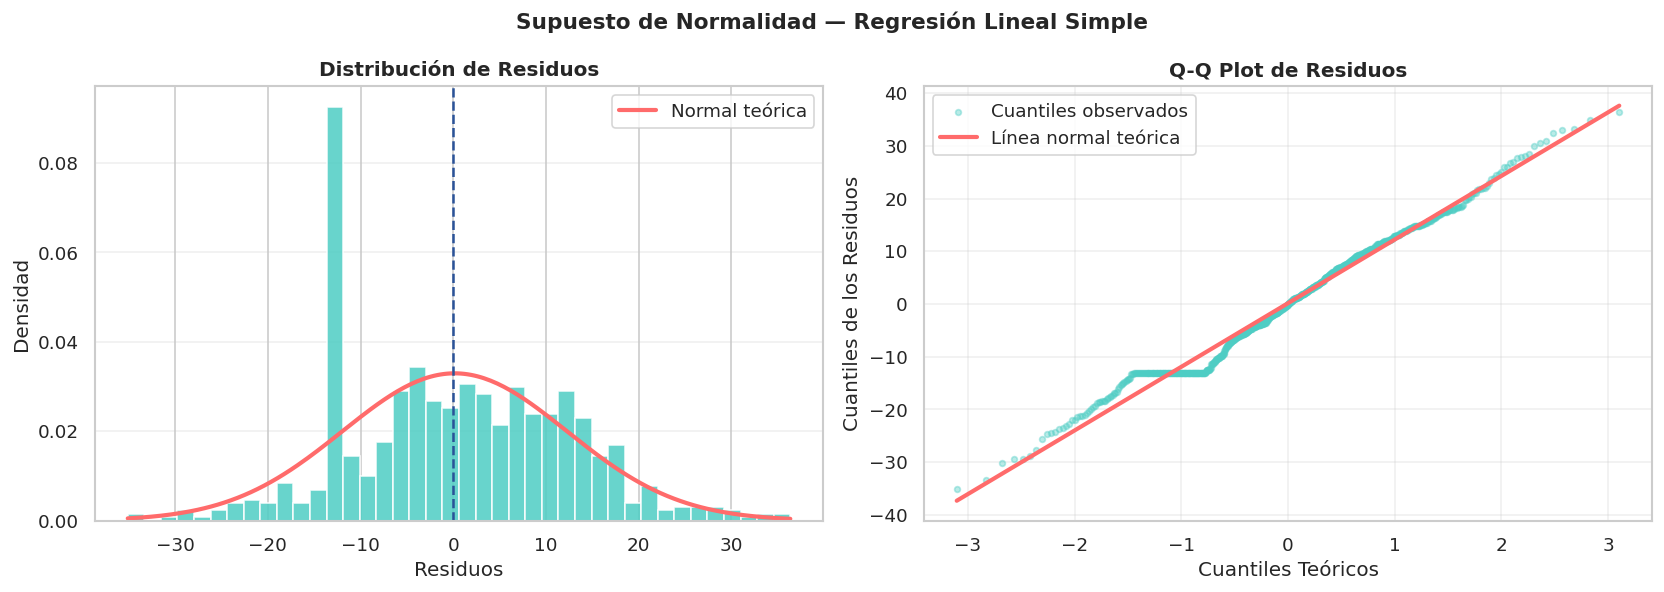


🔬 Test de Shapiro-Wilk:
   Estadístico W : 0.9851
   p-value       : 0.000001
   Conclusión    : ⚠️  Se rechaza normalidad (p ≤ 0.05)
   Nota: Con n ≥ 1000 el test es muy sensible — revisar Q-Q plot


In [14]:
# ── CELDA 14: Normalidad de residuos (modelo simple) ─────────

# Residuos sobre el dataset completo
y_pred_all = modelo_simple.predict(df[['durabilidad']].values)
residuos   = df['promedio_poder'].values - y_pred_all

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Supuesto de Normalidad — Regresión Lineal Simple',
             fontsize=13, fontweight='bold')

# Histograma con curva normal superpuesta
axes[0].hist(residuos, bins=40, color='#4ecdc4', edgecolor='white',
             density=True, alpha=0.85)
xr = np.linspace(residuos.min(), residuos.max(), 200)
axes[0].plot(xr, stats.norm.pdf(xr, residuos.mean(), residuos.std()),
             color='#ff6b6b', linewidth=2.5, label='Normal teórica')
axes[0].axvline(0, color='#2a5298', linestyle='--', linewidth=1.5)
axes[0].set_title('Distribución de Residuos', fontweight='bold')
axes[0].set_xlabel('Residuos')
axes[0].set_ylabel('Densidad')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Q-Q Plot
(osm, osr), (slope, intercept, r) = stats.probplot(residuos, dist='norm')
axes[1].scatter(osm, osr, alpha=0.4, s=12, color='#4ecdc4',
                label='Cuantiles observados')
axes[1].plot(osm, slope * np.array(osm) + intercept,
             color='#ff6b6b', linewidth=2.5, label='Línea normal teórica')
axes[1].set_title('Q-Q Plot de Residuos', fontweight='bold')
axes[1].set_xlabel('Cuantiles Teóricos')
axes[1].set_ylabel('Cuantiles de los Residuos')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/normalidad_superheroes.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Test Shapiro-Wilk
muestra_sw = (residuos if len(residuos) <= 5000
              else np.random.default_rng(42).choice(residuos, 5000,
                                                    replace=False))
stat_sw, p_sw = stats.shapiro(muestra_sw)

print(f"\n🔬 Test de Shapiro-Wilk:")
print(f"   Estadístico W : {stat_sw:.4f}")
print(f"   p-value       : {p_sw:.6f}")
if p_sw > 0.05:
    print("   Conclusión    : ✅ No se rechaza normalidad (p > 0.05)")
else:
    print("   Conclusión    : ⚠️  Se rechaza normalidad (p ≤ 0.05)")
    print("   Nota: Con n ≥ 1000 el test es muy sensible — revisar Q-Q plot")

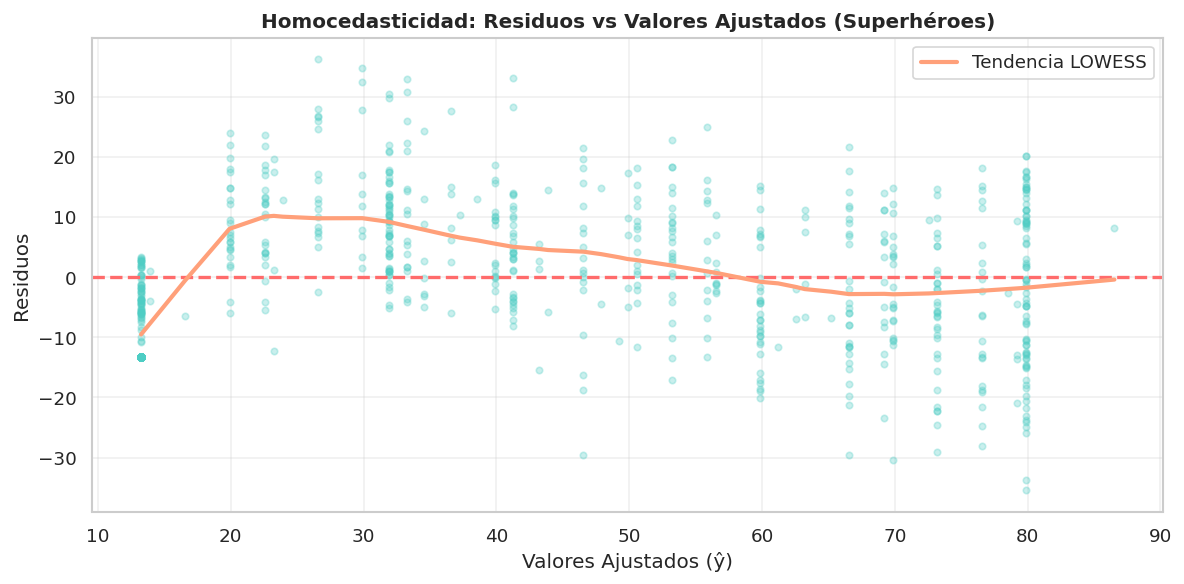


🔬 Test de Breusch-Pagan (Homocedasticidad):
   Estadístico LM : 2.0736
   p-value        : 0.149868
   Conclusión     : ✅ Homocedasticidad (p > 0.05)


In [15]:
# ── CELDA 15: Homocedasticidad (modelo simple) ───────────────

residuos_ols  = modelo_ols_simple.resid
ajustados_ols = modelo_ols_simple.fittedvalues

plt.figure(figsize=(10, 5))
plt.scatter(ajustados_ols, residuos_ols, alpha=0.30, s=15, color='#4ecdc4')
plt.axhline(0, color='#ff6b6b', linestyle='--', linewidth=2)

# Línea de tendencia suavizada LOWESS
lowess = sm.nonparametric.lowess(residuos_ols, ajustados_ols, frac=0.3)
plt.plot(lowess[:, 0], lowess[:, 1], color='#ffa07a', linewidth=2.5,
         label='Tendencia LOWESS')

plt.xlabel('Valores Ajustados (ŷ)', fontsize=12)
plt.ylabel('Residuos', fontsize=12)
plt.title('Homocedasticidad: Residuos vs Valores Ajustados (Superhéroes)',
          fontsize=12, fontweight='bold')

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/homoc_superheroes.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Test de Breusch-Pagan
lm, lm_p, fval, fp = het_breuschpagan(
    residuos_ols,
    modelo_ols_simple.model.exog
)

print(f"\n🔬 Test de Breusch-Pagan (Homocedasticidad):")
print(f"   Estadístico LM : {lm:.4f}")
print(f"   p-value        : {lm_p:.6f}")

if lm_p > 0.05:
    print("   Conclusión     : ✅ Homocedasticidad (p > 0.05)")
else:
    print("   Conclusión     : ⚠️  Heterocedasticidad detectada (p ≤ 0.05)")

In [16]:
# ── PARTICIÓN 60/40 ──
FEATURES = ['inteligencia', 'durabilidad', 'combate']

X_multi = df[FEATURES].values
y       = df['promedio_poder'].values

X_train_60, X_test_60, y_train_60, y_test_60 = train_test_split(
    X_multi, y, test_size=0.40, random_state=42
)

modelo_60 = LinearRegression()
modelo_60.fit(X_train_60, y_train_60)

y_pred_60 = modelo_60.predict(X_test_60)

r2_60 = r2_score(y_test_60, y_pred_60)
rmse_60 = np.sqrt(mean_squared_error(y_test_60, y_pred_60))
mae_60 = mean_absolute_error(y_test_60, y_pred_60)

print("📊 RESULTADOS MODELO 60/40")
print("="*40)
print(f"R²:   {r2_60:.4f}")
print(f"RMSE: {rmse_60:.4f}")
print(f"MAE:  {mae_60:.4f}")

📊 RESULTADOS MODELO 60/40
R²:   0.9190
RMSE: 7.6065
MAE:  6.2000


In [17]:
# ── PARTICIÓN 70/30 ──
X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(
    X_multi, y, test_size=0.30, random_state=42
)

modelo_70 = LinearRegression()
modelo_70.fit(X_train_70, y_train_70)

y_pred_70 = modelo_70.predict(X_test_70)

r2_70 = r2_score(y_test_70, y_pred_70)
rmse_70 = np.sqrt(mean_squared_error(y_test_70, y_pred_70))
mae_70 = mean_absolute_error(y_test_70, y_pred_70)

print("📊 RESULTADOS MODELO 70/30")
print("="*40)
print(f"R²:   {r2_70:.4f}")
print(f"RMSE: {rmse_70:.4f}")
print(f"MAE:  {mae_70:.4f}")

📊 RESULTADOS MODELO 70/30
R²:   0.9205
RMSE: 7.4815
MAE:  6.0847


In [18]:
# ── CELDA 16: Preparación y entrenamiento — modelo múltiple ──
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y, test_size=0.20, random_state=42
)

modelo_multi = LinearRegression()
modelo_multi.fit(X_train_m, y_train_m)

y_pred_multi = modelo_multi.predict(X_test_m)

print(f"Intercepto  β₀              : {modelo_multi.intercept_:.4f}")
for feat, coef in zip(FEATURES, modelo_multi.coef_):
    print(f"Coeficiente {feat:>18} : {coef:.4f}")

Intercepto  β₀              : 3.6890
Coeficiente       inteligencia : 0.2360
Coeficiente        durabilidad : 0.4165
Coeficiente            combate : 0.1897


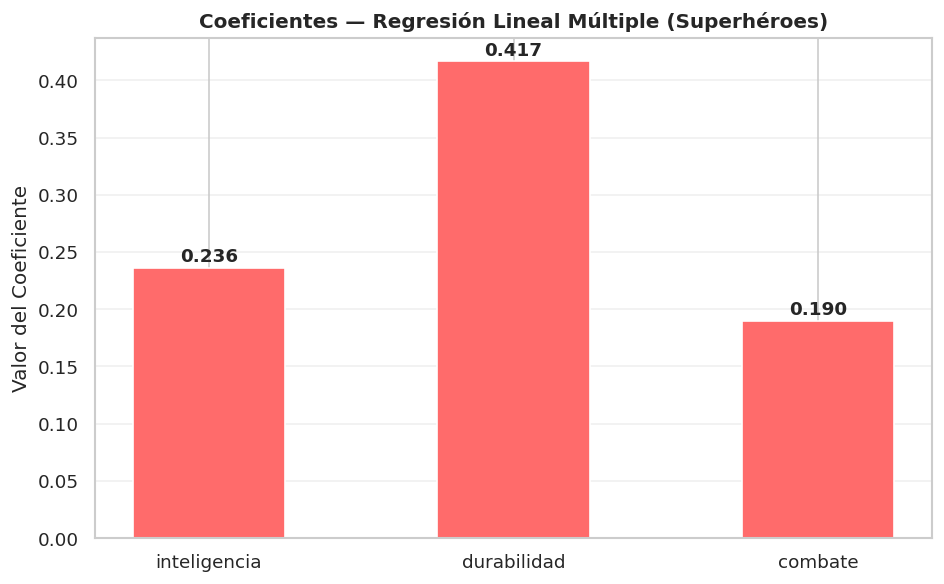

In [19]:
# ── CELDA 17: Gráfica de coeficientes ────────────────────────

colores = ['#ff6b6b' if c > 0 else '#4ecdc4' for c in modelo_multi.coef_]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(FEATURES, modelo_multi.coef_,
              color=colores, edgecolor='white', width=0.5)

ax.axhline(0, color='gray', linestyle='--', linewidth=1)

ax.set_title('Coeficientes — Regresión Lineal Múltiple (Superhéroes)',
             fontsize=12, fontweight='bold')

ax.set_ylabel('Valor del Coeficiente')

# Mostrar valores en las barras
for bar, coef in zip(bars, modelo_multi.coef_):
    offset = 0.002 if coef >= 0 else -0.005
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + offset,
            f'{coef:.3f}',
            ha='center',
            va='bottom',
            fontsize=11,
            fontweight='bold')

ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/coeficientes_multi_superheroes_velocidad.png',
            dpi=150, bbox_inches='tight')

plt.show()

In [20]:
# ── CELDA: Métricas — modelo múltiple ─────────────────────
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

r2_m   = r2_score(y_test_m, y_pred_multi)
mse_m  = mean_squared_error(y_test_m, y_pred_multi)
rmse_m = np.sqrt(mse_m)
mae_m  = mean_absolute_error(y_test_m, y_pred_multi)

print("📊 MÉTRICAS — REGRESIÓN LINEAL MÚLTIPLE")
print("=" * 60)

print(f"🔹 R²   (explicación del modelo)     : {r2_m:.4f}  ({r2_m*100:.2f}%)")
print(f"🔹 MSE  (error cuadrático medio)    : {mse_m:.4f}")
print(f"🔹 RMSE (error típico del modelo)   : {rmse_m:.4f}")
print(f"🔹 MAE  (error absoluto promedio)   : {mae_m:.4f}")

print("=" * 60)

📊 MÉTRICAS — REGRESIÓN LINEAL MÚLTIPLE
🔹 R²   (explicación del modelo)     : 0.9130  (91.30%)
🔹 MSE  (error cuadrático medio)    : 62.6313
🔹 RMSE (error típico del modelo)   : 7.9140
🔹 MAE  (error absoluto promedio)   : 6.3843


In [21]:
# ── CELDA: OLS statsmodels — modelo múltiple ──────────────
import statsmodels.api as sm

# Variables independientes + constante
X_ols_m = sm.add_constant(df[FEATURES])

# Variable dependiente (ajustada a tu caso)
y_ols_m = df['promedio_poder']

# Ajuste del modelo OLS
modelo_ols_multi = sm.OLS(y_ols_m, X_ols_m).fit()

# Resumen completo
print("📊 RESUMEN OLS — REGRESIÓN LINEAL MÚLTIPLE")
print("=" * 70)
print(modelo_ols_multi.summary())

📊 RESUMEN OLS — REGRESIÓN LINEAL MÚLTIPLE
                            OLS Regression Results                            
Dep. Variable:         promedio_poder   R-squared:                       0.919
Model:                            OLS   Adj. R-squared:                  0.919
Method:                 Least Squares   F-statistic:                     2765.
Date:                Thu, 23 Apr 2026   Prob (F-statistic):               0.00
Time:                        16:14:30   Log-Likelihood:                -2524.8
No. Observations:                 731   AIC:                             5058.
Df Residuals:                     727   BIC:                             5076.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const 

In [22]:
# ── CELDA 20: VIF — Factor de Inflación de la Varianza ───────
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = df[FEATURES].copy()

vif_data = pd.DataFrame({
    "Variable": FEATURES,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})

vif_data["VIF"] = vif_data["VIF"].round(3)

vif_data["Criterio"] = vif_data["VIF"].apply(
    lambda v: "Sin multicolinealidad (VIF < 5)"
    if v < 5
    else ("Moderada (5 ≤ VIF < 10)"
          if v < 10
          else "Severa (VIF ≥ 10)")
)

print("\nFACTOR DE INFLACIÓN DE LA VARIANZA (VIF)")
print("=" * 60)
print(vif_data.to_string(index=False))
print("=" * 60)


FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)
    Variable   VIF                        Criterio
inteligencia 8.498         Moderada (5 ≤ VIF < 10)
 durabilidad 4.740 Sin multicolinealidad (VIF < 5)
     combate 7.938         Moderada (5 ≤ VIF < 10)


In [23]:
# ── CELDA 20e: Resumen — Comparación final de correcciones ────
print("📊 RESUMEN — CORRECCIÓN DE MULTICOLINEALIDAD")
print("=" * 65)

resumen_mc = pd.DataFrame({
    'Modelo': [
        'OLS Múltiple (original)',
    ],
    'Variables': [
        ', '.join(FEATURES),
    ],
    'R²': [
        round(r2_m, 4),
    ],
    'RMSE': [
        round(rmse_m, 4),
    ],
})

print(resumen_mc.to_string(index=False))
print("=" * 65)

# Determinar si hubo multicolinealidad
max_vif_original = max(
    variance_inflation_factor(df[FEATURES].values, i)
    for i in range(len(FEATURES))
)

if max_vif_original < 5:
    print(f"\n✅ VIF máximo original = {max_vif_original:.2f} (< 5)")
    print("   No hay multicolinealidad severa en este dataset.")
    print("   El modelo original es estable e interpretable.")
else:
    print(f"\n⚠️  VIF máximo original = {max_vif_original:.2f} (≥ 5)")
    print("   Se detecta multicolinealidad entre las variables explicativas.")

📊 RESUMEN — CORRECCIÓN DE MULTICOLINEALIDAD
                 Modelo                          Variables    R²  RMSE
OLS Múltiple (original) inteligencia, durabilidad, combate 0.913 7.914

⚠️  VIF máximo original = 8.50 (≥ 5)
   Se detecta multicolinealidad entre las variables explicativas.


In [24]:
# ── CELDA 22: Comparación final de modelos ───────────────────
comparacion = pd.DataFrame({
    'Modelo'   : ['Regresión Simple', 'Regresión Múltiple'],
    'Variables': [
        'inteligencia',  
        'inteligencia + durabilidad + combate'
    ],
    'R²'       : [round(r2, 4),    round(r2_m, 4)],
    'R² Aj.'   : [
        round(modelo_ols_simple.rsquared_adj, 4),
        round(modelo_ols_multi.rsquared_adj, 4)
    ],
    'RMSE'     : [round(rmse, 4),  round(rmse_m, 4)],
    'MAE'      : [round(mae, 4),   round(mae_m, 4)],
    'AIC'      : [
        round(modelo_ols_simple.aic, 2),
        round(modelo_ols_multi.aic, 2)
    ],
    'BIC'      : [
        round(modelo_ols_simple.bic, 2),
        round(modelo_ols_multi.bic, 2)
    ],
})

print("=" * 80)
print("              COMPARACIÓN DE MODELOS — SUPERHÉROES")
print("=" * 80)
print(comparacion.to_string(index=False))
print("=" * 80)

print("\n📌 AIC/BIC más bajo → mejor equilibrio entre ajuste y complejidad")

              COMPARACIÓN DE MODELOS — SUPERHÉROES
            Modelo                            Variables     R²  R² Aj.    RMSE    MAE     AIC     BIC
  Regresión Simple                         inteligencia 0.8005  0.7979 11.9833 9.9980 5724.93 5734.12
Regresión Múltiple inteligencia + durabilidad + combate 0.9130  0.9191  7.9140 6.3843 5057.56 5075.94

📌 AIC/BIC más bajo → mejor equilibrio entre ajuste y complejidad


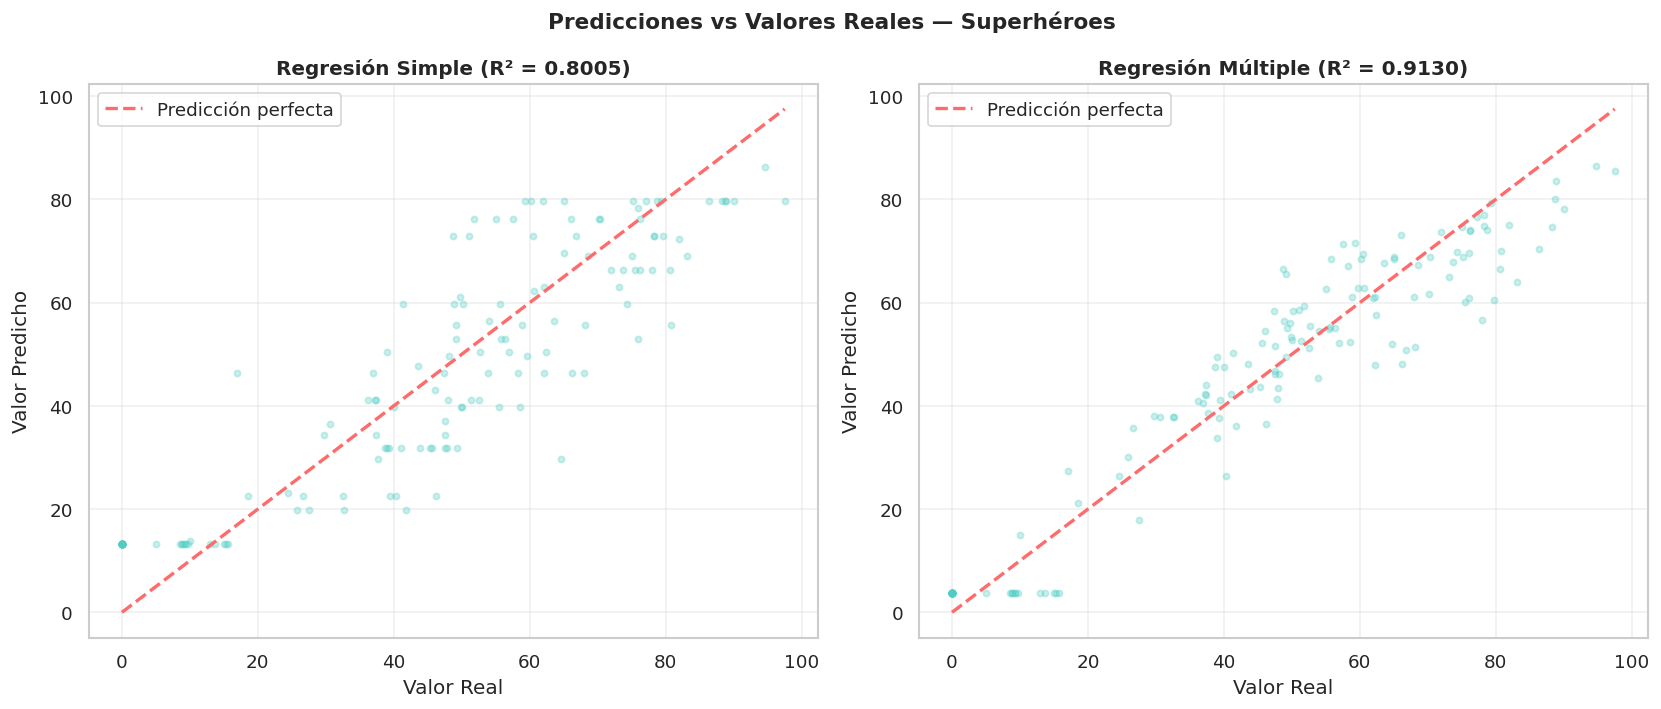

In [25]:
# ── CELDA 23: Predicciones vs Reales — ambos modelos ─────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Predicciones vs Valores Reales — Superhéroes',
             fontsize=13, fontweight='bold')

for ax, (y_real, y_pred, titulo) in zip(axes, [
    (y_test,   y_pred_simple, 'Regresión Simple'),
    (y_test_m, y_pred_multi,  'Regresión Múltiple'),
]):
    minval = min(y_real.min(), y_pred.min())
    maxval = max(y_real.max(), y_pred.max())
    
    ax.scatter(y_real, y_pred, alpha=0.30, s=14, color='#4ecdc4')
    
    # Línea ideal (predicción perfecta)
    ax.plot([minval, maxval], [minval, maxval],
            color='#ff6b6b', linewidth=2, linestyle='--',
            label='Predicción perfecta')
    
    r2_val = r2_score(y_real, y_pred)
    
    ax.set_title(f'{titulo} (R² = {r2_val:.4f})', fontweight='bold')
    ax.set_xlabel('Valor Real')
    ax.set_ylabel('Valor Predicho')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/predicciones_vs_reales_superheroes.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [26]:
import itertools
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import pandas as pd

variables = ['inteligencia', 'durabilidad', 'combate']

resultados = []

for k in range(1, len(variables)+1):
    for combo in itertools.combinations(variables, k):

        X = df[list(combo)]
        y = df['promedio_poder']

        # eliminar nulos
        mask = X.notnull().all(axis=1) & y.notnull()
        X = X.loc[mask]
        y = y.loc[mask]

        # modelo sklearn
        modelo = LinearRegression().fit(X, y)
        y_pred = modelo.predict(X)

        r2 = r2_score(y, y_pred)
        rmse = np.sqrt(mean_squared_error(y, y_pred))

        # modelo statsmodels para residuos
        X_ols = sm.add_constant(X)
        modelo_ols = sm.OLS(y, X_ols).fit()

        lm, pval, _, _ = het_breuschpagan(modelo_ols.resid, X_ols)

        resultados.append({
            'Variables': combo,
            'R2': r2,
            'RMSE': rmse,
            'p-value BP': pval
        })

df_resultados = pd.DataFrame(resultados)

# Ordenar: mejor R² y menor heterocedasticidad
df_resultados.sort_values(by=['R2', 'p-value BP'], ascending=[False, False])

,Variables,R2,RMSE,p-value BP
6,"(inteligencia, durabilidad, combate)",0.919432,7.651750,4.713929e-12
3,"(inteligencia, durabilidad)",0.898930,8.570172,4.796663e-09
5,"(durabilidad, combate)",0.892467,8.839953,8.295616e-11
1,"(durabilidad,)",0.798148,12.111416,1.498677e-01
4,"(inteligencia, combate)",0.743522,13.652241,5.457300e-18
0,"(inteligencia,)",0.672337,15.430926,6.866217e-13
2,"(combate,)",0.641448,16.141891,5.347610e-08


In [27]:
# ── CELDA: Transformación log SOLO en y ─────────────────────

y_log = np.log(df['promedio_poder'] + 1)

X = df[['inteligencia', 'durabilidad', 'combate']]

print("✅ Transformación log aplicada SOLO a y")

✅ Transformación log aplicada SOLO a y


In [28]:
# ── CELDA: Split Train/Test ─────────────────────────────────

mask = X.notnull().all(axis=1) & y_log.notnull()

X = X.loc[mask]
y_log = y_log.loc[mask]

X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.20, random_state=42
)

print(f"Train: {X_train_log.shape[0]:,}")
print(f"Test : {X_test_log.shape[0]:,}")

Train: 584
Test : 147


In [29]:
# ── CELDA: Modelo con log(y) ────────────────────────────────

modelo_log = LinearRegression()
modelo_log.fit(X_train_log, y_train_log)

y_pred_log = modelo_log.predict(X_test_log)

print("🔧 MODELO LOGARÍTMICO (solo y)")
print("=" * 60)

print(f"Intercepto β₀ : {modelo_log.intercept_:.4f}")

for feat, coef in zip(['inteligencia', 'durabilidad', 'combate'], modelo_log.coef_):
    print(f"Coeficiente {feat:>12} : {coef:.4f}")

🔧 MODELO LOGARÍTMICO (solo y)
Intercepto β₀ : 1.2630
Coeficiente inteligencia : 0.0190
Coeficiente  durabilidad : 0.0118
Coeficiente      combate : 0.0110


In [30]:
# ── CELDA: Volver a escala original ─────────────────────────

y_test_orig = np.exp(y_test_log) - 1
y_pred_orig = np.exp(y_pred_log) - 1

In [31]:
# ── CELDA: Métricas en escala original ──────────────────────

r2_log   = r2_score(y_test_orig, y_pred_orig)
rmse_log = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
mae_log  = mean_absolute_error(y_test_orig, y_pred_orig)

print("=" * 60)
print("   MÉTRICAS — MODELO LOG (solo y)")
print("=" * 60)
print(f"R²   : {r2_log:.4f}")
print(f"RMSE : {rmse_log:.4f}")
print(f"MAE  : {mae_log:.4f}")

   MÉTRICAS — MODELO LOG (solo y)
R²   : 0.1987
RMSE : 24.0162
MAE  : 16.9605


In [32]:
# ── CELDA: Diagnóstico ──────────────────────────────────────

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

X_ols = sm.add_constant(X)
modelo_ols_log = sm.OLS(y_log, X_ols).fit()

lm, pval, _, _ = het_breuschpagan(modelo_ols_log.resid,
                                  modelo_ols_log.model.exog)

print("\n🔬 Test Breusch-Pagan (log(y)):")
print(f"p-value: {pval:.6f}")

if pval > 0.05:
    print("✅ Homocedasticidad lograda")
else:
    print("⚠️ Heterocedasticidad persiste")


🔬 Test Breusch-Pagan (log(y)):
p-value: 0.000000
⚠️ Heterocedasticidad persiste
